## Imports

In [1]:
# !pip install -q ../input/landmark-additional-packages/timm-0.3.4-py3-none-any.whl
# !pip install -q ../input/landmark-additional-packages/geffnet-1.0.0-py3-none-any.whl
# !pip install -q ../input/landmark-additional-packages/EfficientNet-PyTorch/EfficientNet-PyTorch-master
!pip install -q ../input/landmark-additional-packages/pycocotools-2.0.2/dist/pycocotools-2.0.2.tar
# !pip install -q ../input/landmark-additional-packages/pretrainedmodels-0.7.4/pretrainedmodels-0.7.4

In [2]:
!pip install "/kaggle/input/hpapytorchzoozip/pytorch_zoo-master"

Processing /kaggle/input/hpapytorchzoozip/pytorch_zoo-master
  Created wheel for pytorch-zoo: filename=pytorch_zoo-0.0.0-py3-none-any.whl size=30139 sha256=bb393fe9e5737dc823f6dc6268778164bb175d92510bb51dae2cdbe797f06aaa
  Stored in directory: /root/.cache/pip/wheels/7a/a2/3c/c273ce5aac2e7c58dd8ecc09794eef80b4a9c43e888738cc10
Successfully built pytorch-zoo


In [3]:
import random
import sys
sys.path.append('../input/hpa-singlecell-e050f56/hpa_singlecell-double_level_valid_all/')

from torch import nn
import torch
import torch.nn.functional as F
import torchvision
from torchvision import transforms
# import timm
from torch.nn.parameter import Parameter
import albumentations as A

from utils import parse_args, prepare_for_result
from torch.utils.data import DataLoader, Dataset
from losses import get_loss, get_class_balanced_weighted
from dataloaders import get_dataloader
from utils import load_matched_state
from configs import Config
from dataloaders.transform_loader import get_tfms

import base64
import zlib
from pycocotools import _mask as coco_mask
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import cv2
import tqdm
import seaborn as sns

import psutil
import os

In [4]:
PUBLIC_TEST = True

In [5]:
def print_memory_usage():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    print(f"RAM Usada: {mem_info.rss / 1024 / 1024:.2f} MB")

## Transforms

In [6]:
tensor_tfms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.485], 
                                             std=[0.229, 0.224, 0.225, 0.229]),
        ])

image_tfms = torchvision.transforms.Compose([
            torchvision.transforms.ToTensor(),
            torchvision.transforms.Normalize(mean=[0.485, 0.456, 0.406, 0.485], 
                                             std=[0.229, 0.224, 0.225, 0.229]),
        ])

tta_tfms = A.Compose([
    A.Resize(always_apply=False, p=1, height=256, width=256, interpolation=1),
    A.HorizontalFlip(always_apply=False, p=0.5),
    A.ShiftScaleRotate(always_apply=False, p=0.7, shift_limit_x=(-0.06, 0.06), shift_limit_y=(-0.06, 0.06), scale_limit=(-0.3, 0.3), rotate_limit=(-22.5, 22.5), interpolation=1, border_mode=2, value=None, mask_value=None),
    A.RandomBrightnessContrast(always_apply=False, p=0.5, brightness_limit=(-0.2, 0.2), contrast_limit=(-0.2, 0.2), brightness_by_max=True),
])

res_tfms = A.Compose([
    A.Resize(always_apply=False, p=1, height=256, width=256, interpolation=1)
])

image_res_tfms = A.Compose([
    A.Resize(always_apply=False, p=1, height=512, width=512, interpolation=1)
])

## Seed

In [7]:
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using GPU

    # For convolutional determinism
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)

## Functions

In [8]:
def binary_mask_to_ascii(mask, mask_val=1):
    """Converts a binary mask into OID challenge encoding ascii text."""
    mask = np.where(mask==mask_val, 1, 0).astype(np.bool)
    
    # check input mask --
    if mask.dtype != np.bool:
        raise ValueError(f"encode_binary_mask expects a binary mask, received dtype == {mask.dtype}")

    mask = np.squeeze(mask)
    if len(mask.shape) != 2:
        raise ValueError(f"encode_binary_mask expects a 2d mask, received shape == {mask.shape}")

    # convert input mask to expected COCO API input --
    mask_to_encode = mask.reshape(mask.shape[0], mask.shape[1], 1)
    mask_to_encode = mask_to_encode.astype(np.uint8)
    mask_to_encode = np.asfortranarray(mask_to_encode)

    # RLE encode mask --
    encoded_mask = coco_mask.encode(mask_to_encode)[0]["counts"]

    # compress and base64 encoding --
    binary_str = zlib.compress(encoded_mask, zlib.Z_BEST_COMPRESSION)
    base64_str = base64.b64encode(binary_str)
    return base64_str.decode()

def squarify(M,val):
    (a,b,c)=M.shape
    if a>b:
        padding=((0,0),((a-b)//2,a-b-(a-b)//2),(0, 0))
    else:
        padding=(((b-a)//2,b-a-(b-a)//2),(0,0),(0, 0))
    return np.pad(M,padding,mode='constant',constant_values=val)

In [9]:
CLASSES = np.asarray([
'0. Nucleoplasm',
'1. Nuclear-membrane',
'2. Nucleoli',
'3. Nucleoli-fibrillar-center',
'4. Nuclear-speckles',
'5. Nuclear-bodies',
'6. Endoplasmic-reticulum',
'7. Golgi apparatus',
'8. Intermediate-filaments',
'9. Actin-filaments',
'10. Microtubules',
'11. Mitotic-spindle',
'12. Centrosome',
'13. Plasma-membrane',
'14. Mitochondria',
'15. Aggresome',
'16. Cytosol',
'17. Vesicles',
'18. Negative'
])

## ResNest269 Model

In [10]:
#@title Model / Architecture

import math
import random

import cv2
import numpy as np

import torch
import torch.nn.functional as F
from torch import nn
from torch.nn import BatchNorm2d, Conv2d, Linear, Module, ReLU
from torch.nn.modules.utils import _pair
import torch.utils.model_zoo as model_zoo
from torch.optim.lr_scheduler import LambdaLR


def set_seed(seed):
  random.seed(seed)
  np.random.seed(seed)

  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


def rotation(x, k):
  return torch.rot90(x, k, (1, 2))


def interleave(x, size):
  s = list(x.shape)
  return x.reshape([-1, size] + s[1:]).transpose(0, 1).reshape([-1] + s[1:])


def de_interleave(x, size):
  s = list(x.shape)
  return x.reshape([size, -1] + s[1:]).transpose(0, 1).reshape([-1] + s[1:])


def resize_tensor(tensors, size, mode='bilinear', align_corners=None):
  return F.interpolate(tensors, size, mode=mode, align_corners=align_corners)


def gap2d(x, keepdims=False):
  x = torch.mean(x.view(x.size(0), x.size(1), -1), -1)
  if keepdims:
    x = x.view(x.size(0), x.size(1), 1, 1)
  return x


# Losses


def L1_Loss(A_tensors, B_tensors):
  return torch.abs(A_tensors - B_tensors)


def L2_Loss(A_tensors, B_tensors):
  return torch.pow(A_tensors - B_tensors, 2)


# ratio = 0.2, top=20%
def Online_Hard_Example_Mining(values, ratio=0.2):
  b, c, h, w = values.size()
  return torch.topk(values.reshape(b, -1), k=int(c * h * w * ratio), dim=-1)[0]


def shannon_entropy_loss(logits, activation=torch.sigmoid, epsilon=1e-5):
  v = activation(logits)
  return -torch.sum(v * torch.log(v + epsilon), dim=1).mean()


def make_cam(x, eps=1e-5, shift_min=False, global_norm=False, inplace=True):
  x = F.relu(x)

  if global_norm:
    x_min = x.min() if shift_min else 0
    x_max = x.max() - x_min
  else:
    b, c, h, w = x.size()
    flat_x = x.view(b, c, -1)
    x_min = flat_x.min(axis=-1)[0].view((b, c, 1, 1)) if shift_min else 0
    x_max = flat_x.max(axis=-1)[0].view((b, c, 1, 1)) - x_min

  if shift_min:
    if inplace:
      x -= x_min
      x /= x_max + eps
    else:
      x = (x - x_min) / (x_max + eps)
  else:
    if inplace:
      x /= x_max + eps
    else:
      x = x / (x_max + eps)

  return x


def one_hot_embedding(label, classes):
  """Embedding labels to one-hot form.

    Args:
      labels: (int) class labels.
      num_classes: (int) number of classes.

    Returns:
      (tensor) encoded labels, sized [N, #classes].
    """

  vector = np.zeros((classes), dtype=np.float)
  if len(label) > 0:
    vector[label] = 1.
  return vector


def calculate_parameters(model):
  return sum(param.numel() for param in model.parameters()) / 1000000.0


def get_learning_rate_from_optimizer(optimizer):
  return optimizer.param_groups[0]['lr']


def set_trainable_layers(model, klass=None, trainable=False):
  for m in model.modules():
    if klass is None or isinstance(m, klass):
      for prop in ("weight", "bias"):
        w = getattr(m, prop, None)
        if w is not None:
          w.requires_grad = trainable


def to_numpy(tensor):
  return tensor.cpu().detach().numpy()


def load_model(model, model_path, parallel=False, map_location=None, strict=True):
  print(f'loading weights from `{model_path}`.')

  state = torch.load(model_path, map_location=map_location)
  if parallel:
    model.module.load_state_dict(state, strict=strict)
  else:
    model.load_state_dict(state, strict=strict)


def save_model(model, model_path, parallel=False):
  print(f'saving weights to `{model_path}`.')

  if parallel:
    torch.save(model.module.state_dict(), model_path)
  else:
    torch.save(model.state_dict(), model_path)


def transfer_model(pretrained_model, model):
  pretrained_dict = pretrained_model.state_dict()
  model_dict = model.state_dict()

  pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in model_dict}

  model_dict.update(pretrained_dict)
  model.load_state_dict(model_dict)


def get_learning_rate(optimizer):
  lr = []
  for param_group in optimizer.param_groups:
    lr += [param_group['lr']]
  return lr


def get_cosine_schedule_with_warmup(optimizer, warmup_iteration, max_iteration, cycles=7. / 16.):

  def _lr_lambda(current_iteration):
    if current_iteration < warmup_iteration:
      return float(current_iteration) / float(max(1, warmup_iteration))

    no_progress = float(current_iteration - warmup_iteration) / float(max(1, max_iteration - warmup_iteration))
    return max(0., math.cos(math.pi * cycles * no_progress))

  return LambdaLR(optimizer, _lr_lambda, -1)


def label_smoothing(labels, alpha):
  if alpha:
    return (1 - alpha) * labels + alpha * 0.5

  return labels


class SplAtConv2d(Module):
  """Split-Attention Conv2d
    """

  def __init__(
    self,
    in_channels,
    channels,
    kernel_size,
    stride=(1, 1),
    padding=(0, 0),
    dilation=(1, 1),
    groups=1,
    bias=True,
    radix=2,
    reduction_factor=4,
    rectify=False,
    rectify_avg=False,
    norm_layer=None,
    dropblock_prob=0.0,
    **kwargs
  ):
    super(SplAtConv2d, self).__init__()
    padding = _pair(padding)
    self.rectify = rectify and (padding[0] > 0 or padding[1] > 0)
    self.rectify_avg = rectify_avg
    inter_channels = max(in_channels * radix // reduction_factor, 32)
    self.radix = radix
    self.cardinality = groups
    self.channels = channels
    self.dropblock_prob = dropblock_prob
    if self.rectify:
      from rfconv import RFConv2d
      self.conv = RFConv2d(
        in_channels,
        channels * radix,
        kernel_size,
        stride,
        padding,
        dilation,
        groups=groups * radix,
        bias=bias,
        average_mode=rectify_avg,
        **kwargs
      )
    else:
      self.conv = Conv2d(
        in_channels,
        channels * radix,
        kernel_size,
        stride,
        padding,
        dilation,
        groups=groups * radix,
        bias=bias,
        **kwargs
      )
    self.use_bn = norm_layer is not None
    if self.use_bn:
      self.bn0 = norm_layer(channels * radix)
    self.relu = ReLU(inplace=True)
    self.fc1 = Conv2d(channels, inter_channels, 1, groups=self.cardinality)
    if self.use_bn:
      self.bn1 = norm_layer(inter_channels)
    self.fc2 = Conv2d(inter_channels, channels * radix, 1, groups=self.cardinality)
    if dropblock_prob > 0.0:
      self.dropblock = DropBlock2D(dropblock_prob, 3)
    self.rsoftmax = rSoftMax(radix, groups)

  def forward(self, x):
    x = self.conv(x)
    if self.use_bn:
      x = self.bn0(x)
    if self.dropblock_prob > 0.0:
      x = self.dropblock(x)
    x = self.relu(x)

    batch, rchannel = x.shape[:2]
    if self.radix > 1:
      if torch.__version__ < '1.5':
        splited = torch.split(x, int(rchannel // self.radix), dim=1)
      else:
        splited = torch.split(x, rchannel // self.radix, dim=1)
      gap = sum(splited)
    else:
      gap = x
    gap = F.adaptive_avg_pool2d(gap, 1)
    gap = self.fc1(gap)

    if self.use_bn:
      gap = self.bn1(gap)
    gap = self.relu(gap)

    atten = self.fc2(gap)
    atten = self.rsoftmax(atten).view(batch, -1, 1, 1)

    if self.radix > 1:
      if torch.__version__ < '1.5':
        attens = torch.split(atten, int(rchannel // self.radix), dim=1)
      else:
        attens = torch.split(atten, rchannel // self.radix, dim=1)
      out = sum([att * split for (att, split) in zip(attens, splited)])
    else:
      out = atten * x
    return out.contiguous()


class rSoftMax(nn.Module):

  def __init__(self, radix, cardinality):
    super().__init__()
    self.radix = radix
    self.cardinality = cardinality

  def forward(self, x):
    batch = x.size(0)
    if self.radix > 1:
      x = x.view(batch, self.cardinality, self.radix, -1).transpose(1, 2)
      x = F.softmax(x, dim=1)
      x = x.reshape(batch, -1)
    else:
      x = torch.sigmoid(x)
    return x


class DropBlock2D(object):

  def __init__(self, *args, **kwargs):
    raise NotImplementedError


class GlobalAvgPool2d(nn.Module):

  def __init__(self):
    """Global average pooling over the input's spatial dimensions"""
    super(GlobalAvgPool2d, self).__init__()

  def forward(self, inputs):
    return nn.functional.adaptive_avg_pool2d(inputs, 1).view(inputs.size(0), -1)


class Bottleneck(nn.Module):
  """ResNet Bottleneck
    """
  # pylint: disable=unused-argument
  expansion = 4

  def __init__(
    self,
    inplanes,
    planes,
    stride=1,
    downsample=None,
    radix=1,
    cardinality=1,
    bottleneck_width=64,
    avd=False,
    avd_first=False,
    dilation=1,
    is_first=False,
    rectified_conv=False,
    rectify_avg=False,
    norm_layer=None,
    dropblock_prob=0.0,
    last_gamma=False
  ):
    super(Bottleneck, self).__init__()
    group_width = int(planes * (bottleneck_width / 64.)) * cardinality
    self.conv1 = nn.Conv2d(inplanes, group_width, kernel_size=1, bias=False)
    self.bn1 = norm_layer(group_width)
    self.dropblock_prob = dropblock_prob
    self.radix = radix
    self.avd = avd and (stride > 1 or is_first)
    self.avd_first = avd_first

    if self.avd:
      self.avd_layer = nn.AvgPool2d(3, stride, padding=1)
      stride = 1

    if dropblock_prob > 0.0:
      self.dropblock1 = DropBlock2D(dropblock_prob, 3)
      if radix == 1:
        self.dropblock2 = DropBlock2D(dropblock_prob, 3)
      self.dropblock3 = DropBlock2D(dropblock_prob, 3)

    if radix >= 1:
      self.conv2 = SplAtConv2d(
        group_width,
        group_width,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        dilation=dilation,
        groups=cardinality,
        bias=False,
        radix=radix,
        rectify=rectified_conv,
        rectify_avg=rectify_avg,
        norm_layer=norm_layer,
        dropblock_prob=dropblock_prob
      )
    elif rectified_conv:
      from rfconv import RFConv2d
      self.conv2 = RFConv2d(
        group_width,
        group_width,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        dilation=dilation,
        groups=cardinality,
        bias=False,
        average_mode=rectify_avg
      )
      self.bn2 = norm_layer(group_width)
    else:
      self.conv2 = nn.Conv2d(
        group_width,
        group_width,
        kernel_size=3,
        stride=stride,
        padding=dilation,
        dilation=dilation,
        groups=cardinality,
        bias=False
      )
      self.bn2 = norm_layer(group_width)

    self.conv3 = nn.Conv2d(group_width, planes * 4, kernel_size=1, bias=False)
    self.bn3 = norm_layer(planes * 4)

    if last_gamma:
      from torch.nn.init import zeros_
      zeros_(self.bn3.weight)
    self.relu = nn.ReLU(inplace=True)
    self.downsample = downsample
    self.dilation = dilation
    self.stride = stride

  def forward(self, x):
    residual = x

    out = self.conv1(x)
    out = self.bn1(out)
    if self.dropblock_prob > 0.0:
      out = self.dropblock1(out)
    out = self.relu(out)

    if self.avd and self.avd_first:
      out = self.avd_layer(out)

    out = self.conv2(out)
    if self.radix == 0:
      out = self.bn2(out)
      if self.dropblock_prob > 0.0:
        out = self.dropblock2(out)
      out = self.relu(out)

    if self.avd and not self.avd_first:
      out = self.avd_layer(out)

    out = self.conv3(out)
    out = self.bn3(out)
    if self.dropblock_prob > 0.0:
      out = self.dropblock3(out)

    if self.downsample is not None:
      residual = self.downsample(x)

    out += residual
    out = self.relu(out)

    return out


class ResNet(nn.Module):
  """ResNet Variants

    Parameters
    ----------
    block : Block
        Class for the residual block. Options are BasicBlockV1, BottleneckV1.
    layers : list of int
        Numbers of layers in each block
    classes : int, default 1000
        Number of classification classes.
    dilated : bool, default False
        Applying dilation strategy to pretrained ResNet yielding a stride-8 model,
        typically used in Semantic Segmentation.
    norm_layer : object
        Normalization layer used in backbone network (default: :class:`mxnet.gluon.nn.BatchNorm`;
        for Synchronized Cross-GPU BachNormalization).

    Reference:

        - He, Kaiming, et al. "Deep residual learning for image recognition." Proceedings of the IEEE conference on computer vision and pattern recognition. 2016.

        - Yu, Fisher, and Vladlen Koltun. "Multi-scale context aggregation by dilated convolutions."
    """

  # pylint: disable=unused-variable
  def __init__(
    self,
    block,
    layers,
    radix=1,
    groups=1,
    bottleneck_width=64,
    num_classes=1000,
    dilated=False,
    dilation=1,
    deep_stem=False,
    stem_width=64,
    avg_down=False,
    rectified_conv=False,
    rectify_avg=False,
    avd=False,
    avd_first=False,
    final_drop=0.0,
    dropblock_prob=0,
    last_gamma=False,
    norm_layer=nn.BatchNorm2d
  ):
    self.cardinality = groups
    self.bottleneck_width = bottleneck_width
    # ResNet-D params
    self.stage_features = []
    self.outplanes = self.inplanes = stem_width * 2 if deep_stem else 64
    self.avg_down = avg_down
    self.last_gamma = last_gamma
    # ResNeSt params
    self.radix = radix
    self.avd = avd
    self.avd_first = avd_first

    super(ResNet, self).__init__()
    self.rectified_conv = rectified_conv
    self.rectify_avg = rectify_avg
    if rectified_conv:
      from rfconv import RFConv2d
      conv_layer = RFConv2d
    else:
      conv_layer = nn.Conv2d
    conv_kwargs = {'average_mode': rectify_avg} if rectified_conv else {}
    if deep_stem:
      self.conv1 = nn.Sequential(
        conv_layer(3, stem_width, kernel_size=3, stride=2, padding=1, bias=False, **conv_kwargs),
        norm_layer(stem_width),
        nn.ReLU(inplace=True),
        conv_layer(stem_width, stem_width, kernel_size=3, stride=1, padding=1, bias=False, **conv_kwargs),
        norm_layer(stem_width),
        nn.ReLU(inplace=True),
        conv_layer(stem_width, stem_width * 2, kernel_size=3, stride=1, padding=1, bias=False, **conv_kwargs),
      )
    else:
      self.conv1 = conv_layer(3, 64, kernel_size=7, stride=2, padding=3, bias=False, **conv_kwargs)
    self.bn1 = norm_layer(self.inplanes)
    self.relu = nn.ReLU(inplace=True)
    self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
    self.layer1 = self._make_layer(block, 64, layers[0], norm_layer=norm_layer, is_first=False)
    self.layer2 = self._make_layer(block, 128, layers[1], stride=2, norm_layer=norm_layer)
    if dilated or dilation == 4:
      self.layer3 = self._make_layer(
        block, 256, layers[2], stride=1, dilation=2, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )
      self.layer4 = self._make_layer(
        block, 512, layers[3], stride=1, dilation=4, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )
    elif dilation == 2:
      self.layer3 = self._make_layer(
        block, 256, layers[2], stride=2, dilation=1, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )
      self.layer4 = self._make_layer(
        block, 512, layers[3], stride=1, dilation=2, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )
    else:
      self.layer3 = self._make_layer(
        block, 256, layers[2], stride=2, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )
      self.layer4 = self._make_layer(
        block, 512, layers[3], stride=2, norm_layer=norm_layer, dropblock_prob=dropblock_prob
      )

    self.avgpool = GlobalAvgPool2d()
    self.drop = nn.Dropout(final_drop) if final_drop > 0.0 else None
    self.fc = nn.Linear(512 * block.expansion, num_classes)

    for m in self.modules():
      if isinstance(m, nn.Conv2d):
        n = m.kernel_size[0] * m.kernel_size[1] * m.out_channels
        m.weight.data.normal_(0, math.sqrt(2. / n))
      elif isinstance(m, norm_layer):
        m.weight.data.fill_(1)
        m.bias.data.zero_()

  def _make_layer(
    self, block, planes, blocks, stride=1, dilation=1, norm_layer=None, dropblock_prob=0.0, is_first=True
  ):
    downsample = None
    if stride != 1 or self.inplanes != planes * block.expansion:
      down_layers = []
      if self.avg_down:
        if dilation == 1:
          down_layers.append(nn.AvgPool2d(kernel_size=stride, stride=stride, ceil_mode=True, count_include_pad=False))
        else:
          down_layers.append(nn.AvgPool2d(kernel_size=1, stride=1, ceil_mode=True, count_include_pad=False))
        down_layers.append(nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=1, bias=False))
      else:
        down_layers.append(nn.Conv2d(self.inplanes, planes * block.expansion, kernel_size=1, stride=stride, bias=False))
      down_layers.append(norm_layer(planes * block.expansion))
      downsample = nn.Sequential(*down_layers)

    layers = []
    if dilation == 1 or dilation == 2:
      layers.append(
        block(
          self.inplanes,
          planes,
          stride,
          downsample=downsample,
          radix=self.radix,
          cardinality=self.cardinality,
          bottleneck_width=self.bottleneck_width,
          avd=self.avd,
          avd_first=self.avd_first,
          dilation=1,
          is_first=is_first,
          rectified_conv=self.rectified_conv,
          rectify_avg=self.rectify_avg,
          norm_layer=norm_layer,
          dropblock_prob=dropblock_prob,
          last_gamma=self.last_gamma
        )
      )
    elif dilation == 4:
      layers.append(
        block(
          self.inplanes,
          planes,
          stride,
          downsample=downsample,
          radix=self.radix,
          cardinality=self.cardinality,
          bottleneck_width=self.bottleneck_width,
          avd=self.avd,
          avd_first=self.avd_first,
          dilation=2,
          is_first=is_first,
          rectified_conv=self.rectified_conv,
          rectify_avg=self.rectify_avg,
          norm_layer=norm_layer,
          dropblock_prob=dropblock_prob,
          last_gamma=self.last_gamma
        )
      )
    else:
      raise RuntimeError("=> unknown dilation size: {}".format(dilation))

    self.outplanes = self.inplanes = planes * block.expansion
    self.stage_features.append(self.outplanes)

    for i in range(1, blocks):
      layers.append(
        block(
          self.inplanes,
          planes,
          radix=self.radix,
          cardinality=self.cardinality,
          bottleneck_width=self.bottleneck_width,
          avd=self.avd,
          avd_first=self.avd_first,
          dilation=dilation,
          rectified_conv=self.rectified_conv,
          rectify_avg=self.rectify_avg,
          norm_layer=norm_layer,
          dropblock_prob=dropblock_prob,
          last_gamma=self.last_gamma
        )
      )

    return nn.Sequential(*layers)

  def forward(self, x):
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.maxpool(x)

    x1 = self.layer1(x)
    x2 = self.layer2(x1)
    x3 = self.layer3(x2)
    x4 = self.layer4(x3)

    # print(x.size())

    # x = self.avgpool(x)
    #x = x.view(x.size(0), -1)
    # x = torch.flatten(x, 1)
    # if self.drop:
    #   x = self.drop(x)
    # x = self.fc(x)

    return (x1, x2, x3, x4)

_url_format = 'https://github.com/zhanghang1989/ResNeSt/releases/download/weights_step1/{}-{}.pth'

_model_sha256 = {
  name: checksum for checksum, name in [
    ('528c19ca', 'resnest50'),
    ('22405ba7', 'resnest101'),
    ('75117900', 'resnest200'),
    ('0cc87c48', 'resnest269'),
  ]
}


def short_hash(name):
  if name not in _model_sha256:
    raise ValueError('Pretrained model for {name} is not available.'.format(name=name))
  return _model_sha256[name][:8]


resnest_model_urls = {name: _url_format.format(name, short_hash(name)) for name in _model_sha256.keys()}


def resnest50(pretrained=False, root='~/.encoding/models', **kwargs):
  model = ResNet(
    Bottleneck, [3, 4, 6, 3],
    radix=2,
    groups=1,
    bottleneck_width=64,
    deep_stem=True,
    stem_width=32,
    avg_down=True,
    avd=True,
    avd_first=False,
    **kwargs
  )
  if pretrained:
    model.load_state_dict(
      torch.hub.load_state_dict_from_url(resnest_model_urls['resnest50'], progress=True, check_hash=True)
    )
  return model


def resnest101(pretrained=False, root='~/.encoding/models', **kwargs):
  model = ResNet(
    Bottleneck, [3, 4, 23, 3],
    radix=2,
    groups=1,
    bottleneck_width=64,
    deep_stem=True,
    stem_width=64,
    avg_down=True,
    avd=True,
    avd_first=False,
    **kwargs
  )
  if pretrained:
    model.load_state_dict(
      torch.hub.load_state_dict_from_url(resnest_model_urls['resnest101'], progress=True, check_hash=True)
    )
  return model


def resnest200(pretrained=False, root='~/.encoding/models', **kwargs):
  model = ResNet(
    Bottleneck, [3, 24, 36, 3],
    radix=2,
    groups=1,
    bottleneck_width=64,
    deep_stem=True,
    stem_width=64,
    avg_down=True,
    avd=True,
    avd_first=False,
    **kwargs
  )
  if pretrained:
    model.load_state_dict(
      torch.hub.load_state_dict_from_url(resnest_model_urls['resnest200'], progress=True, check_hash=True)
    )
  return model


def resnest269(pretrained=False, root='~/.encoding/models', **kwargs):
  model = ResNet(
    Bottleneck, [3, 30, 48, 8],
    radix=2,
    groups=1,
    bottleneck_width=64,
    deep_stem=True,
    stem_width=64,
    avg_down=True,
    avd=True,
    avd_first=False,
    **kwargs
  )
  if pretrained:
    model.load_state_dict(
      torch.hub.load_state_dict_from_url(resnest_model_urls['resnest269'], progress=True, check_hash=True)
    )
  return model


class FixedBatchNorm(nn.BatchNorm2d):

  def forward(self, x):
    return F.batch_norm(x, self.running_mean, self.running_var, self.weight, self.bias, training=False, eps=self.eps)


def group_norm(features):
  return nn.GroupNorm(4, features)


#######################################################################

def patch_conv_in_channels(model, layer_name, new_in_channels, copying_channel=0):
  layer = getattr(model, layer_name)  # layer = model.conv1
  # new_layer = layer.clone().detach()

  if isinstance(layer, nn.Sequential):
    cv_layers = list(layer.children())
    cv = cv_layers[0]
  else:
    cv = layer

  if not isinstance(cv, nn.Conv2d):
    raise ValueError(f"Cannot extract Conv2d from {cv}.")

  new_cv = nn.Conv2d(
    in_channels=new_in_channels,
    out_channels=cv.out_channels,
    kernel_size=cv.kernel_size,
    stride=cv.stride,
    padding=cv.padding,
    bias=cv.bias).requires_grad_()

  with torch.no_grad():
    new_cv.weight[:, :cv.in_channels, :, :] = cv.weight.data

    for i in range(new_in_channels - cv.in_channels):
        channel = cv.in_channels + i
        new_cv.weight[:, channel:channel+1, :, :] = cv.weight[:, copying_channel:copying_channel+1, : :].data
  new_cv.weight = nn.Parameter(new_cv.weight)

  if isinstance(layer, nn.Sequential):
    new_cv = nn.Sequential(new_cv, *cv_layers[1:])

  setattr(model, layer_name, new_cv)  # model.conv1 = new_layer


def build_backbone(name, dilated, strides, norm_fn, weights='imagenet', channels=3, **kwargs):
  dilation = 4 if dilated else 2

  pretrained = weights == "imagenet"
  model_fn = globals()[name]
  model = model_fn(pretrained=pretrained, dilated=dilated, dilation=dilation, norm_layer=norm_fn)
  if channels != 3:
    patch_conv_in_channels(model, "conv1", channels)
  if pretrained:
    print(f'loading weights from {resnest_model_urls[name]}')

  del model.avgpool
  del model.fc

  if weights and weights != 'imagenet':
    print(f'loading weights from {weights}')
    checkpoint = torch.load(weights, map_location="cpu")
    model.load_state_dict(checkpoint['state_dict'], strict=False)

  stages = (
    nn.Sequential(model.conv1, model.bn1, model.relu, model.maxpool),
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4,
  )

  return model, stages


class Backbone(nn.Module):

  def __init__(
    self,
    model_name,
    weights='imagenet',
    channels=3,
    mode='fix',
    dilated=False,
    strides=None,
    trainable_stem=True,
    trainable_stage4=True,
    trainable_backbone=True,
    backbone_kwargs={},
  ):
    super().__init__()

    self.mode = mode
    self.trainable_stem = trainable_stem
    self.trainable_stage4 = trainable_stage4
    self.trainable_backbone = trainable_backbone
    self.not_training = []
    self.from_scratch_layers = []

    if mode == 'normal':
      self.norm_fn = nn.BatchNorm2d
    elif mode == 'fix':
      self.norm_fn = FixedBatchNorm
    else:
      raise ValueError(f'Unknown mode {mode}. Must be `normal` or `fix`.')

    backbone, stages = build_backbone(
      model_name, dilated, strides, self.norm_fn, weights, channels, **backbone_kwargs,
    )

    self.backbone = backbone
    self.stages = stages

    if not self.trainable_backbone:
      for s in stages:
        set_trainable_layers(s, trainable=False)
      self.not_training.extend(stages)
    else:
      if not self.trainable_stage4:
        self.not_training.extend(stages[:-1])
        for s in stages[:-1]:
          set_trainable_layers(s, trainable=False)

      elif not self.trainable_stem:
        set_trainable_layers(stages[0], trainable=False)
        self.not_training.append(stages[0])

      if self.mode == "fix":
        for s in stages:
          set_trainable_layers(s, torch.nn.BatchNorm2d, trainable=False)
          self.not_training.extend([m for m in s.modules() if isinstance(m, torch.nn.BatchNorm2d)])

  def initialize(self, modules):
    for m in modules:
      if isinstance(m, nn.Conv2d):
        torch.nn.init.kaiming_normal_(m.weight)
      elif isinstance(m, nn.Linear):
        nn.init.trunc_normal_(m.weight, std=.02)
        if isinstance(m, nn.Linear) and m.bias is not None:
            nn.init.constant_(m.bias, 0)
      elif isinstance(m, (nn.BatchNorm2d, nn.SyncBatchNorm, nn.GroupNorm, nn.LayerNorm)):
        nn.init.constant_(m.weight, 1.0)
        nn.init.constant_(m.bias, 0)

  def get_parameter_groups(self, exclude_partial_names=(), with_names=False):
    names = ([], [], [], [])
    groups = ([], [], [], [])

    scratch_parameters = set()
    all_parameters = set()

    for layer in self.from_scratch_layers:
      for name, param in layer.named_parameters():
        if param in all_parameters:
          continue
        scratch_parameters.add(param)
        all_parameters.add(param)

        if not param.requires_grad:
          continue
        for p in exclude_partial_names:
          if p in name:
            continue

        idx = 2 if "weight" in name else 3
        names[idx].append(name)
        groups[idx].append(param)

    for name, param in self.named_parameters():
      if param in all_parameters:
        continue
      all_parameters.add(param)

      if not param.requires_grad or param in scratch_parameters:
        continue
      for p in exclude_partial_names:
        if p in name:
          continue

      idx = 0 if "weight" in name else 1
      names[idx].append(name)
      groups[idx].append(param)

    if with_names:
      return groups, names

    return groups

  def train(self, mode=True):
    super().train(mode)
    for m in self.not_training:
      m.eval()
    return self


def gem(x, p=3, eps=1e-6):
    return F.avg_pool2d(x.clamp(min=eps).pow(p), (x.size(-2), x.size(-1))).pow(1./p)


class GeM(nn.Module):
    def __init__(self, p=3, eps=1e-6):
        super(GeM,self).__init__()
        self.p = Parameter(torch.ones(1)*p)
        self.eps = eps

    def forward(self, x):
        return gem(x, p=self.p, eps=self.eps)

    def __repr__(self):
        return self.__class__.__name__ + '(' + 'p=' + '{:.4f}'.format(self.p.data.tolist()[0]) + ', ' + 'eps=' + str(self.eps) + ')'


class CellClassifier(Backbone):

  def __init__(
    self,
    model_name,
    num_classes=20,
    backbone_weights="imagenet",
    channels=3,
    mode='fix',
    dilated=False,
    strides=None,
    trainable_stem=True,
    trainable_stage4=True,
    trainable_backbone=True,
    **backbone_kwargs,
  ):
    super().__init__(
      model_name,
      channels=channels,
      weights=backbone_weights,
      mode=mode,
      dilated=dilated,
      strides=strides,
      trainable_stem=trainable_stem,
      trainable_stage4=trainable_stage4,
      trainable_backbone=trainable_backbone,
      backbone_kwargs=backbone_kwargs,
    )

    self.num_classes = num_classes

    cin = self.backbone.outplanes
    self.classifier = nn.Conv2d(cin, num_classes, 1, bias=False)

    self.from_scratch_layers.extend([self.classifier])
    self.initialize([self.classifier])

    self.pool = GeM()
    self.flatten = nn.Flatten()
    self.dropout = nn.Dropout(p=0.5)

    self.last_linear_cell = nn.Linear(
      in_features=cin, 
      out_features=num_classes)
    self.last_linear_image = nn.Linear(
      in_features=cin, 
      out_features=num_classes)

  def forward(self, x, cnt=16, with_cam=False):
    if with_cam:
      raise NotImplementedError(
        "CAM not currently supported in multi-view mode")

    outs = self.backbone(x)
    features = outs[-1] if isinstance(outs, tuple) else outs

    pooled = self.flatten(self.pool(features))
    viewed_pooled = pooled.view(-1, cnt, pooled.shape[-1])
    viewed_pooled = viewed_pooled.max(1)[0]

    cell_logits = self.last_linear_cell(pooled)
    image_logits = self.last_linear_image(viewed_pooled)

    return cell_logits, image_logits


class CellClassifierV2(Backbone):

  def __init__(
    self,
    model_name,
    num_classes=20,
    backbone_weights="imagenet",
    channels=3,
    mode='fix',
    dilated=False,
    strides=None,
    trainable_stem=True,
    trainable_stage4=True,
    trainable_backbone=True,
    **backbone_kwargs,
  ):
    super().__init__(
      model_name,
      channels=channels,
      weights=backbone_weights,
      mode=mode,
      dilated=dilated,
      strides=strides,
      trainable_stem=trainable_stem,
      trainable_stage4=trainable_stage4,
      trainable_backbone=trainable_backbone,
      backbone_kwargs=backbone_kwargs,
    )

    self.num_classes = num_classes
    cin = self.backbone.outplanes

    self.pool = GeM()
    self.flatten = nn.Flatten()
    self.dropout = nn.Dropout(p=0.5)

    self.last_linear_cell = nn.Linear(
      in_features=cin, 
      out_features=num_classes)
    self.last_linear_image = nn.Linear(
      in_features=cin, 
      out_features=num_classes)
    
    self.from_scratch_layers.extend([self.last_linear_cell, self.last_linear_image])
    self.initialize([self.last_linear_cell, self.last_linear_image])

  def forward(self, x, cnt=16, with_cam=False, cell_logits_to_image_logits=False):
    cnt = torch.tensor(cnt)
    if with_cam:
      raise NotImplementedError(
        "CAM not currently supported in multi-view mode")

    outs = self.backbone(x)
    features = outs[-1] if isinstance(outs, tuple) else outs

    pooled = self.flatten(self.pool(features))

    if cell_logits_to_image_logits:
      cell_logits = self.last_linear_cell(pooled)
      cell_logits_split = torch.split(cell_logits, cnt.tolist())
      image_logits = torch.stack([p.max(0).values for p in cell_logits_split])

      return cell_logits, image_logits

    pooled_split = torch.split(pooled, cnt.tolist())
    pooled_per_img = torch.stack([p.max(0)[0] for p in pooled_split])

    cell_logits = self.last_linear_cell(pooled)
    image_logits = self.last_linear_image(pooled_per_img)

    return cell_logits, image_logits


class ImageClassifier(Backbone):

  def __init__(
    self,
    model_name,
    num_classes=20,
    backbone_weights="imagenet",
    channels=3,
    mode='fix',
    dilated=False,
    strides=None,
    trainable_stem=True,
    trainable_stage4=True,
    trainable_backbone=True,
    **backbone_kwargs,
  ):
    super().__init__(
      model_name,
      channels=channels,
      weights=backbone_weights,
      mode=mode,
      dilated=dilated,
      strides=strides,
      trainable_stem=trainable_stem,
      trainable_stage4=trainable_stage4,
      trainable_backbone=trainable_backbone,
      backbone_kwargs=backbone_kwargs,
    )

    self.num_classes = num_classes

    cin = self.backbone.outplanes
    self.classifier = nn.Conv2d(cin, num_classes, 1, bias=False)

    self.from_scratch_layers.extend([self.classifier])
    self.initialize([self.classifier])

  def forward(self, x, with_cam=False):
    outs = self.backbone(x)
    x = outs[-1] if isinstance(outs, tuple) else outs

    if with_cam:
      features = self.classifier(x)
      logits = gap2d(features)
      return logits, features
    else:
      x = gap2d(x, keepdims=True)
      logits = self.classifier(x).view(-1, self.num_classes)
      return logits

## Load ResNest269 Model

In [11]:
models = []
image_models = []

In [12]:
WEIGHTS_PATHS = [
    '/kaggle/input/models/julianamidlej/rs50-dino-20e-no-freeze/pytorch/default/1/hpa2nd-rs50-lr0.0002-b6-aug2nd-adamw-eid-down-task-dino/model-f5-e19.pth']
DEVICE = 'cuda'

for weights_path in WEIGHTS_PATHS:
    model = CellClassifier(
        'resnest50',
        19,
        channels=4,
        mode='normal',
        dilated=False,
        backbone_weights=None,
    )
    load_model(model, weights_path, map_location=torch.device(DEVICE))
    model.eval()

    models.append(model)

loading weights from `/kaggle/input/models/julianamidlej/rs50-dino-20e-no-freeze/pytorch/default/1/hpa2nd-rs50-lr0.0002-b6-aug2nd-adamw-eid-down-task-dino/model-f5-e19.pth`.


In [13]:
# WEIGHTS_PATHS = [
#     '/kaggle/input/models/julianamidlej/base-ema-mixup-crop-res-m1/pytorch/default/1/hpa-512-rs269-lr0.1-b16-ls0.1-mixup-ema1-cp-m1.pth']
# DEVICE = 'cuda'

# for weights_path in WEIGHTS_PATHS:
#     model = ImageClassifier(
#         'resnest269',
#         19,
#         channels=4,
#         mode='normal',
#         dilated=False,
#         backbone_weights=None,
#     )
#     load_model(model, weights_path, map_location=torch.device(DEVICE))
#     model.eval()

#     image_models.append(model)

## Loading models
* b3
* b5
* r50d
* r200d
* se50

In [14]:
# model_paths = [
#     '/kaggle/input/b3/pytorch/default/1/b3/checkpoints/f0_epoch-18.pth',
#     '/kaggle/input/b3-f1/pytorch/default/1/b3_F1/checkpoints/f1_epoch-16.pth',
#     '/kaggle/input/b3-f2/pytorch/default/1/b3_F2/checkpoints/f2_epoch-17.pth',
#     '/kaggle/input/b3-f3/pytorch/default/1/b3_F3/checkpoints/f3_epoch-19.pth',
#     '/kaggle/input/b3-f4/pytorch/default/1/b3_F4/checkpoints/f4_epoch-18.pth'
# ]

# for model_path in model_paths:
#     cfg = Config.load_json('/kaggle/input/b3/pytorch/default/1/b3/config.json')
#     model = get_model(cfg).cuda()
#     load_matched_state(model, torch.load(model_path))
#     _ = model.eval()
#     models.append(model)

In [15]:
# model_paths = [
#     '/kaggle/input/b5/pytorch/default/1/b5/checkpoints/f0_epoch-14.pth',
#     '/kaggle/input/b5-f1/pytorch/default/1/b5_F1/checkpoints/f1_epoch-14.pth',
#     '/kaggle/input/b5-f2/pytorch/default/1/b5_F2/checkpoints/f2_epoch-15.pth',
#     '/kaggle/input/b5-f3-v2/pytorch/default/1/b5_F3/checkpoints/f3_epoch-17.pth',
#     '/kaggle/input/b5-f4/pytorch/default/1/b5_F4/checkpoints/f4_epoch-14.pth'   
# ]

# for model_path in model_paths:
#     cfg = Config.load_json('/kaggle/input/b5/pytorch/default/1/b5/config.json')
#     model = get_model(cfg).cuda()
#     load_matched_state(model, torch.load(model_path))
#     _ = model.eval()
#     models.append(model)

In [16]:
# model_paths = [
#     '/kaggle/input/r50-f0/pytorch/default/1/r50_F0/checkpoints/f0_epoch-14.pth',
#     '/kaggle/input/r50-f1/pytorch/default/1/r50_F1/checkpoints/f1_epoch-14.pth',
#     '/kaggle/input/r50-f2/pytorch/default/1/r50_F2/checkpoints/f2_epoch-13.pth',
#     '/kaggle/input/r50-f3/pytorch/default/1/r50_F3/checkpoints/f3_epoch-15.pth',
#     '/kaggle/input/r50-f4/pytorch/default/1/r50_F4/checkpoints/f4_epoch-14.pth'
# ]

# for model_path in model_paths:
#     cfg = Config.load_json('/kaggle/input/r50-f0/pytorch/default/1/r50_F0/config.json')
#     model = get_model(cfg).cuda()
#     load_matched_state(model, torch.load(model_path))
#     _ = model.eval()
#     models.append(model)

In [17]:
# !cp ../input/landmark-additional-packages/resnet200d_ra2-bdba9bf9.pth /root/.cache/torch/hub/checkpoints/

In [18]:
# model_paths = [
#     '/kaggle/input/r200/pytorch/default/1/r200d/checkpoints/f0_epoch-13.pth',
#     '/kaggle/input/r200-f1/pytorch/default/1/r200d_F1/checkpoints/f1_epoch-15.pth',
#     '/kaggle/input/r200-f2/pytorch/default/1/r200d_F2/checkpoints/f2_epoch-15.pth',
#     '/kaggle/input/r200-f3/pytorch/default/1/r200d_F3/checkpoints/f3_epoch-14.pth',
#     '/kaggle/input/r200-f4/pytorch/default/1/r200d_F4/checkpoints/f4_epoch-14.pth'
# ]

# for model_path in model_paths:
#     cfg = Config.load_json('/kaggle/input/r200/pytorch/default/1/r200d/config.json')
#     model = get_model(cfg).cuda()
#     load_matched_state(model, torch.load(model_path))
#     _ = model.eval()
#     models.append(model)

In [19]:
# model_paths = [
#     '/kaggle/input/se50/pytorch/default/1/se50/checkpoints/f0_epoch-18.pth',
#     '/kaggle/input/se50-f1/pytorch/default/1/se50_F1/checkpoints/f1_epoch-19.pth',
#     '/kaggle/input/se50-f2/pytorch/default/1/se50_F2/checkpoints/f2_epoch-18.pth',
#     '/kaggle/input/se50-f3/pytorch/default/1/se50_F3/checkpoints/f3_epoch-18.pth',
#     '/kaggle/input/se50-f4/pytorch/default/1/se50_F4/checkpoints/f4_epoch-18.pth'
# ]

# for model_path in model_paths:
#     cfg = Config.load_json('/kaggle/input/se50/pytorch/default/1/se50/config.json')
#     model = get_model(cfg).cuda()
#     load_matched_state(model, torch.load(model_path))
#     _ = model.eval()
#     models.append(model)

In [20]:
print(len(models))
print(len(image_models))

1
0


## Cell Segmentator

In [21]:
def __fill_holes(image):
    """Fill_holes for labelled image, with a unique number."""
    boundaries = segmentation.find_boundaries(image)
    image = np.multiply(image, np.invert(boundaries))
    image = ndi.binary_fill_holes(image > 0)
    image = ndi.label(image)[0]
    return image

def label_cell_vlad(nuclei_pred, cell_pred, img_size=512, return_nuclei_label=True):
    """Label the cells and the nuclei.

    Keyword arguments:
    nuclei_pred -- a 3D numpy array of a prediction from a nuclei image.
    cell_pred -- a 3D numpy array of a prediction from a cell image.

    Returns:
    A tuple containing:
    nuclei-label -- A nuclei mask data array.
    cell-label  -- A cell mask data array.

    0's in the data arrays indicate background while a continous
    strech of a specific number indicates the area for a specific
    cell.
    The same value in cell mask and nuclei mask refers to the identical cell.

    NOTE: The nuclei labeling from this function will be sligthly
    different from the values in :func:`label_nuclei` as this version
    will use information from the cell-predictions to make better
    estimates.
    """
    def __wsh(
        mask_img,
        threshold,
        border_img,
        seeds,
        threshold_adjustment=0.35,
        small_object_size_cutoff=10,
    ):
        img_copy = np.zeros_like(mask_img)
        m = seeds * border_img  # * dt
        img_copy[m > threshold + threshold_adjustment] = 1
        img_copy = img_copy.astype(np.bool)
        img_copy = remove_small_objects(img_copy, small_object_size_cutoff).astype(
            np.uint8
        )

        mask_img = np.where(mask_img <= threshold, 0, 1)
        mask_img = mask_img.astype(np.bool)
        
        ### New segmentation ###
        mask_img = remove_small_holes(mask_img, int(63 * (img_size / 512)**2))
        ########################
        
        mask_img = remove_small_objects(mask_img, 8).astype(np.uint8)
        markers = ndi.label(img_copy, output=np.uint32)[0]
        labeled_array = segmentation.watershed(
            mask_img, markers, mask=mask_img, watershed_line=True
        )
        return labeled_array

    nuclei_label = __wsh(
        nuclei_pred[..., 2] / 255.0,
        0.4,
        1 - (nuclei_pred[..., 1] + cell_pred[..., 1]) / 255.0 > 0.05,
        nuclei_pred[..., 2] / 255,
        threshold_adjustment=-0.25,
        small_object_size_cutoff=32,
    )

    # for hpa_image, to remove the small pseduo nuclei
    
    ### New segmentation ###
    nuclei_label = remove_small_objects(nuclei_label, int(157 * (img_size / 512)**2))
    ########################
    
    nuclei_label = measure.label(nuclei_label)
    # this is to remove the cell borders' signal from cell mask.
    # could use np.logical_and with some revision, to replace this func.
    # Tuned for segmentation hpa images
    threshold_value = max(0.22, filters.threshold_otsu(cell_pred[..., 2] / 255) * 0.5)
    # exclude the green area first
    cell_region = np.multiply(
        cell_pred[..., 2] / 255 > threshold_value,
        np.invert(np.asarray(cell_pred[..., 1] / 255 > 0.05, dtype=np.int8)),
    )
    sk = np.asarray(cell_region, dtype=np.int8)
    
    ################### CHANGES HERE ###################################
 
    ####################### V4 ####################
    distance_old = np.clip(cell_pred[..., 2], 255 * threshold_value, cell_pred[..., 2])
    cell_label_old = segmentation.watershed(-distance_old, nuclei_label, mask=sk)
    
    ### New segmentation ###
    cell_label_old = remove_small_objects(cell_label_old, int(344 * (img_size / 512)**2)).astype(np.uint8)
    ########################
    
    distance = distance_old.copy()
    distance[distance<225] = 0
    
    cell_label = segmentation.watershed(-distance, nuclei_label, mask=distance)
    
    ### New segmentation ###
    cell_label = remove_small_objects(cell_label, int(344 * (img_size / 512)**2)).astype(np.uint8)
    ########################
    
    unqs = np.unique(cell_label)
    if 0 in unqs:
        unqs = unqs[1:]
        
    lst = [cv2.dilate((cell_label==unq).astype(np.uint8), kernel=np.ones((10, 10), np.uint8), iterations=1) for unq in unqs]
    cell_label = np.zeros_like(cell_label)
    
    for i, l in enumerate(lst):
        cell_label[l==True] = unqs[i]
                
    for unq in unqs:
        smth = cell_label_old==unq
        if True not in smth[0,:] and True not in smth[-1,:] and True not in smth[:,0] and True not in smth[:,-1]:
            cell_label[cell_label==unq] = 0
            cell_label[cell_label_old==unq] = unq
            
    ################### CHANGES HERE ###################################
    
#     selem = disk(max(1, int(6 * 2048 / img_size)))
    selem = disk(6)
    cell_label = closing(cell_label, selem)
    cell_label = __fill_holes(cell_label)
    # this part is to use green channel, and extend cell label to green channel
    # benefit is to exclude cells clear on border but without nucleus
    sk = np.asarray(
        np.add(
            np.asarray(cell_label > 0, dtype=np.int8),
            np.asarray(cell_pred[..., 1] / 255 > 0.05, dtype=np.int8),
        )
        > 0,
        dtype=np.int8,
    )
    cell_label = segmentation.watershed(-distance, cell_label, mask=sk)
    cell_label = __fill_holes(cell_label)
    cell_label = np.asarray(cell_label > 0, dtype=np.uint8)
    cell_label = measure.label(cell_label)
    
    ### New segmentation ###
    cell_label = remove_small_objects(cell_label, int(344 * (img_size / 512)**2))
    ########################
    
    cell_label = measure.label(cell_label)
    cell_label = np.asarray(cell_label, dtype=np.uint16)
    if not return_nuclei_label:
        return cell_label
    nuclei_label = np.multiply(cell_label > 0, nuclei_label) > 0
    nuclei_label = measure.label(nuclei_label)
    
    ### New segmentation ###
    nuclei_label = remove_small_objects(nuclei_label, int(157 * (img_size / 512)**2))
    ########################
    
    nuclei_label = np.multiply(cell_label, nuclei_label > 0)

    return nuclei_label, cell_label

def label_cell(nuclei_pred, cell_pred):
    """Label the cells and the nuclei.

    Keyword arguments:
    nuclei_pred -- a 3D numpy array of a prediction from a nuclei image.
    cell_pred -- a 3D numpy array of a prediction from a cell image.

    Returns:
    A tuple containing:
    nuclei-label -- A nuclei mask data array.
    cell-label  -- A cell mask data array.

    0's in the data arrays indicate background while a continous
    strech of a specific number indicates the area for a specific
    cell.
    The same value in cell mask and nuclei mask refers to the identical cell.

    NOTE: The nuclei labeling from this function will be sligthly
    different from the values in :func:`label_nuclei` as this version
    will use information from the cell-predictions to make better
    estimates.
    """
    def __wsh(
        mask_img,
        threshold,
        border_img,
        seeds,
        threshold_adjustment=0.35,
        small_object_size_cutoff=10,
    ):
        img_copy = np.copy(mask_img)
        m = seeds * border_img  # * dt
        img_copy[m <= threshold + threshold_adjustment] = 0
        img_copy[m > threshold + threshold_adjustment] = 1
        img_copy = img_copy.astype(np.bool)
        img_copy = remove_small_objects(img_copy, small_object_size_cutoff).astype(
            np.uint8
        )

        mask_img[mask_img <= threshold] = 0
        mask_img[mask_img > threshold] = 1
        mask_img = mask_img.astype(np.bool)
        mask_img = remove_small_holes(mask_img, 1000)
        mask_img = remove_small_objects(mask_img, 8).astype(np.uint8)
        markers = ndi.label(img_copy, output=np.uint32)[0]
        labeled_array = segmentation.watershed(
            mask_img, markers, mask=mask_img, watershed_line=True
        )
        return labeled_array

    nuclei_label = __wsh(
        nuclei_pred[..., 2] / 255.0,
        0.4,
        1 - (nuclei_pred[..., 1] + cell_pred[..., 1]) / 255.0 > 0.05,
        nuclei_pred[..., 2] / 255,
        threshold_adjustment=-0.25,
        small_object_size_cutoff=500,
    )

    # for hpa_image, to remove the small pseduo nuclei
    nuclei_label = remove_small_objects(nuclei_label, 2500)
    nuclei_label = measure.label(nuclei_label)
    # this is to remove the cell borders' signal from cell mask.
    # could use np.logical_and with some revision, to replace this func.
    # Tuned for segmentation hpa images
    threshold_value = max(0.22, filters.threshold_otsu(cell_pred[..., 2] / 255) * 0.5)
    # exclude the green area first
    cell_region = np.multiply(
        cell_pred[..., 2] / 255 > threshold_value,
        np.invert(np.asarray(cell_pred[..., 1] / 255 > 0.05, dtype=np.int8)),
    )
    sk = np.asarray(cell_region, dtype=np.int8)
    distance = np.clip(cell_pred[..., 2], 255 * threshold_value, cell_pred[..., 2])
    cell_label = segmentation.watershed(-distance, nuclei_label, mask=sk)
    cell_label = remove_small_objects(cell_label, 5500).astype(np.uint8)
    selem = disk(6)
    cell_label = closing(cell_label, selem)
    cell_label = __fill_holes(cell_label)
    # this part is to use green channel, and extend cell label to green channel
    # benefit is to exclude cells clear on border but without nucleus
    sk = np.asarray(
        np.add(
            np.asarray(cell_label > 0, dtype=np.int8),
            np.asarray(cell_pred[..., 1] / 255 > 0.05, dtype=np.int8),
        )
        > 0,
        dtype=np.int8,
    )
    cell_label = segmentation.watershed(-distance, cell_label, mask=sk)
    cell_label = __fill_holes(cell_label)
    cell_label = np.asarray(cell_label > 0, dtype=np.uint8)
    cell_label = measure.label(cell_label)
    cell_label = remove_small_objects(cell_label, 5500)
    cell_label = measure.label(cell_label)
    cell_label = np.asarray(cell_label, dtype=np.uint16)
    nuclei_label = np.multiply(cell_label > 0, nuclei_label) > 0
    nuclei_label = measure.label(nuclei_label)
    nuclei_label = remove_small_objects(nuclei_label, 2500)
    nuclei_label = np.multiply(cell_label, nuclei_label > 0)

    return nuclei_label, cell_label

In [22]:
def read_img(image_id_path):
    img = cv2.imread(image_id_path, 0)
    return img

def load_RGBY_images(image_id_path):
    
    red_image = read_img(image_id_path+"_red.png")
    green_image = read_img(image_id_path+"_green.png")
    blue_image = read_img(image_id_path+"_blue.png")
    yellow_image = read_img(image_id_path+"_yellow.png")
    
    return red_image, green_image, blue_image, yellow_image

def encode_binary_mask(mask):

    if mask.dtype != np.bool:
        raise ValueError("encode_binary_mask expects a binary mask, received dtype == %s" % mask.dtype)

    mask = np.squeeze(mask)
    if len(mask.shape) != 2:
        raise ValueError("encode_binary_mask expects a 2d mask, received shape == %s" % mask.shape)
    
    mask = mask.astype(np.uint8)
    
    mask_to_encode = mask.reshape(mask.shape[0], mask.shape[1], 1)
    mask_to_encode = np.asfortranarray(mask_to_encode)
    
    encoded_mask = coco_mask.encode(mask_to_encode)[0]["counts"]
    
    binary_str = zlib.compress(encoded_mask, zlib.Z_BEST_COMPRESSION)
    base64_str = base64.b64encode(binary_str)
    
    return base64_str.decode()

def compute_M(data):
    cols = np.arange(data.size)
    return csr_matrix((cols, (data.ravel(), cols)), shape=(data.max() + 1, data.size))

def get_indices_sparse(data):
    M = compute_M(data)
    return [np.unravel_index(row.data, data.shape) for row in M]

class CellSegmentator(object):
    """Uses pretrained DPN-Unet models to segment cells from images."""

    NORMALIZE = {"mean": [124 / 255, 117 / 255, 104 / 255], "std": [1 / (0.0167 * 255)] * 3}
    
    def __init__(
            self,
            nuclei_model="./nuclei_model.pth",
            cell_model="./cell_model.pth",
            model_width_height=None,
            device="cuda",
            multi_channel_model=True,
            return_without_scale_restore=False,
            scale_factor=0.25,
            padding=False
    ):

        if device != "cuda" and device != "cpu" and "cuda" not in device:
            raise ValueError(f"{device} is not a valid device (cuda/cpu)")
        if device != "cpu":
            try:
                assert torch.cuda.is_available()
            except AssertionError:
                print("No GPU found, using CPU.", file=sys.stderr)
                device = "cpu"
                
        self.device = device

        if isinstance(nuclei_model, str):
            if not os.path.exists(nuclei_model):
                print(
                    f"Could not find {nuclei_model}. Downloading it now",
                    file=sys.stderr,
                )
                download_with_url(NUCLEI_MODEL_URL, nuclei_model)
            nuclei_model = torch.load(
                nuclei_model, map_location=torch.device(self.device)
            )
        if isinstance(nuclei_model, torch.nn.DataParallel) and device == "cpu":
            nuclei_model = nuclei_model.module

        self.nuclei_model = nuclei_model.to(self.device)

        self.multi_channel_model = multi_channel_model
        if isinstance(cell_model, str):
            if not os.path.exists(cell_model):
                print(
                    f"Could not find {cell_model}. Downloading it now", file=sys.stderr
                )
                if self.multi_channel_model:
                    download_with_url(MULTI_CHANNEL_CELL_MODEL_URL, cell_model)
                else:
                    download_with_url(TWO_CHANNEL_CELL_MODEL_URL, cell_model)
            cell_model = torch.load(cell_model, map_location=torch.device(self.device))
        self.cell_model = cell_model.to(self.device)
        self.model_width_height = model_width_height
        self.return_without_scale_restore = return_without_scale_restore
        self.scale_factor = scale_factor
        self.padding = padding

    def _image_conversion(self, images):

        microtubule_imgs, er_imgs, nuclei_imgs = images
        if self.multi_channel_model:
            if not isinstance(er_imgs, list):
                raise ValueError("Please speicify the image path(s) for er channels!")
        else:
            if not er_imgs is None:
                raise ValueError(
                    "second channel should be None for two channel model predition!"
                )

        if not isinstance(microtubule_imgs, list):
            raise ValueError("The microtubule images should be a list")
        if not isinstance(nuclei_imgs, list):
            raise ValueError("The microtubule images should be a list")

        if er_imgs:
            if not len(microtubule_imgs) == len(er_imgs) == len(nuclei_imgs):
                raise ValueError("The lists of images needs to be the same length")
        else:
            if not len(microtubule_imgs) == len(nuclei_imgs):
                raise ValueError("The lists of images needs to be the same length")

        if not all(isinstance(item, np.ndarray) for item in microtubule_imgs):
            microtubule_imgs = [
                os.path.expanduser(item) for _, item in enumerate(microtubule_imgs)
            ]
            nuclei_imgs = [
                os.path.expanduser(item) for _, item in enumerate(nuclei_imgs)
            ]

            microtubule_imgs = list(
                map(lambda item: imageio.imread(item), microtubule_imgs)
            )
            nuclei_imgs = list(map(lambda item: imageio.imread(item), nuclei_imgs))
            if er_imgs:
                er_imgs = [os.path.expanduser(item) for _, item in enumerate(er_imgs)]
                er_imgs = list(map(lambda item: imageio.imread(item), er_imgs))

        if not er_imgs:
            er_imgs = [
                np.zeros(item.shape, dtype=item.dtype)
                for _, item in enumerate(microtubule_imgs)
            ]
        cell_imgs = list(
            map(
                lambda item: np.dstack((item[0], item[1], item[2])),
                list(zip(microtubule_imgs, er_imgs, nuclei_imgs)),
            )
        )

        return cell_imgs

    def _pad(self, image):
        
        rows, cols = image.shape[:2]
        self.scaled_shape = rows, cols
        img_pad= cv2.copyMakeBorder(
                    image,
                    32,
                    (32 - rows % 32),
                    32,
                    (32 - cols % 32),
                    cv2.BORDER_REFLECT,
                )
        
        return img_pad

    def pred_nuclei(self, images):

        def _preprocess(images):
            if isinstance(images[0], str):
                raise NotImplementedError('Currently the model requires images as numpy arrays, not paths.')
                # images = [imageio.imread(image_path) for image_path in images]
            self.target_shapes = [image.shape for image in images]
            #print(images.shape)
            #resize like in original implementation with https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize
            if self.model_width_height:
                images = np.array([transform.resize(image, (self.model_width_height,self.model_width_height)) 
                                  for image in images])
            else:
                images = [transform.rescale(image, self.scale_factor) for image in images]

            if self.padding:
                images = [self._pad(image) for image in images]

            nuc_images = np.array([np.dstack((image[..., 2], image[..., 2], image[..., 2])) if len(image.shape) >= 3
                                   else np.dstack((image, image, image)) for image in images])
            
            nuc_images = nuc_images.transpose([0, 3, 1, 2])
            #print("nuc", nuc_images.shape)

            return nuc_images

        def _segment_helper(imgs):
            with torch.no_grad():
                mean = torch.as_tensor(self.NORMALIZE["mean"], device=self.device)
                std = torch.as_tensor(self.NORMALIZE["std"], device=self.device)
                imgs = torch.tensor(imgs).float()
                imgs = imgs.to(self.device)
                imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])

                imgs = self.nuclei_model(imgs)
                imgs = F.softmax(imgs, dim=1)
                return imgs

        preprocessed_imgs = _preprocess(images)
        predictions = _segment_helper(preprocessed_imgs)
        predictions = predictions.to("cpu").numpy()
        #dont restore scaling, just save and scale later ...
        predictions = [self._restore_scaling(util.img_as_ubyte(pred), target_shape)
                       for pred, target_shape in zip(predictions, self.target_shapes)]
        return predictions

    def _restore_scaling(self, n_prediction, target_shape):
        """Restore an image from scaling and padding.
        This method is intended for internal use.
        It takes the output from the nuclei model as input.
        """
        n_prediction = n_prediction.transpose([1, 2, 0])
        if self.padding:
            n_prediction = n_prediction[
                32 : 32 + self.scaled_shape[0], 32 : 32 + self.scaled_shape[1], ...
            ]
        n_prediction[..., 0] = 0
        if not self.return_without_scale_restore:
            n_prediction = cv2.resize(
                n_prediction,
                (target_shape[0], target_shape[1]),
                #try INTER_NEAREST_EXACT
                interpolation=cv2.INTER_AREA,
            )
        return n_prediction

    def pred_cells(self, images, precombined=False):

        def _preprocess(images):
            self.target_shapes = [image.shape for image in images]
            for image in images:
                if not len(image.shape) == 3:
                    raise ValueError("image should has 3 channels")
            #resize like in original implementation with https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.resize
            if self.model_width_height:
                images = np.array([transform.resize(image, (self.model_width_height,self.model_width_height)) 
                                  for image in images])
            else:
                images = np.array([transform.rescale(image, self.scale_factor, multichannel=True) for image in images])

            if self.padding:
                images = np.array([self._pad(image) for image in images])

            cell_images = images.transpose([0, 3, 1, 2])

            return cell_images

        def _segment_helper(imgs):
            with torch.no_grad():
                mean = torch.as_tensor(self.NORMALIZE["mean"], device=self.device)
                std = torch.as_tensor(self.NORMALIZE["std"], device=self.device)
                imgs = torch.tensor(imgs).float()
                imgs = imgs.to(self.device)
                imgs = imgs.sub_(mean[:, None, None]).div_(std[:, None, None])
                imgs = self.cell_model(imgs)
                imgs = F.softmax(imgs, dim=1)
                return imgs

        if not precombined:
            images = self._image_conversion(images)
        preprocessed_imgs = _preprocess(images)
        predictions = _segment_helper(preprocessed_imgs)
        predictions = predictions.to("cpu").numpy()
        predictions = [self._restore_scaling(util.img_as_ubyte(pred), target_shape)
                       for pred, target_shape in zip(predictions, self.target_shapes)]
        
        return predictions

In [23]:
# 2nd
# NUC_MODEL = '/kaggle/input/hpamisc/HPA-Cell-Segmentation-weights/dpn_unet_nuclei_v1.pth'
# CELL_MODEL = '/kaggle/input/hpamisc/HPA-Cell-Segmentation-weights/dpn_unet_cell_3ch_v1.pth'
import os

# Lucas
NUC_MODEL = '/kaggle/input/hpacellsegmentatormodelweights/dpn_unet_nuclei_v1.pth'
CELL_MODEL = '/kaggle/input/hpacellsegmentatormodelweights/dpn_unet_cell_3ch_v1.pth'

SEGMENTATION_SCALE=0.25
segmentator = CellSegmentator(
    NUC_MODEL,
    CELL_MODEL,
    device="cuda",
    multi_channel_model=True,
    scale_factor=SEGMENTATION_SCALE,
    padding=True,
    return_without_scale_restore=True
)

please compile abn


/opt/conda/lib/python3.7/site-packages/torch/serialization.py:658: SourceChangeWarning: source code of class 'pytorch_zoo.unet.DPNUnet' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/opt/conda/lib/python3.7/site-packages/torch/serialization.py:658: SourceChangeWarning: source code of class 'torch.nn.modules.container.ModuleList' has changed. you can retrieve the original source code by accessing the object's source attribute or set `torch.nn.Module.dump_patches = True` and use the patch tool to revert the changes.
  warnings.warn(msg, SourceChangeWarning)
/opt/conda/lib/python3.7/site-packages/torch/serialization.py:658: SourceChangeWarning: source code of class 'torch.nn.modules.container.Sequential' has changed. you can retrieve the original source code by accessing the object's source attribute or set

In [24]:
def remove_small_nuclei_on_border(nuclei_mask, nuclei_area_thresh=0.5):
    
    h,w = nuclei_mask.shape[:2]
    
    touching_border = []
    
    nuclei_uniques = np.unique(nuclei_mask)
    if 0 in nuclei_uniques:
        nuclei_uniques = nuclei_uniques[1:]
        
    for unq in nuclei_uniques:
        idxs = np.where(nuclei_mask==unq)
        y_min, y_max = min(idxs[0]), max(idxs[0])
        x_min, x_max = min(idxs[1]), max(idxs[1])
        if x_min == 0 or y_min == 0 or x_max == (w - 1) or y_max == (h - 1):
            touching_border.append(unq)
    
    nuclei_areas = np.array([np.count_nonzero(nuclei_mask==unq) for unq in nuclei_uniques])
    not_touching_border_idxs = [i for i, unq in enumerate(nuclei_uniques) if unq not in touching_border]

    ignore_nuclei_idxs = nuclei_uniques[(nuclei_areas < np.median(nuclei_areas[not_touching_border_idxs])*nuclei_area_thresh) & np.isin(nuclei_uniques, touching_border)]
    
    return ignore_nuclei_idxs

def do_segmentation(ryb_image, blue_image):
    
    img_size = blue_image.shape[0] * SEGMENTATION_SCALE

    nuc_segmentation = segmentator.pred_nuclei([blue_image])
    cell_segmentation = segmentator.pred_cells([ryb_image], precombined=True)
    
    nuclei_mask, cell_mask = label_cell_vlad(nuc_segmentation[0], cell_segmentation[0], img_size, return_nuclei_label=True)
    
    cell_mask = cell_mask.astype(np.uint8)

    # Remove border cells with nuclei_area < median/2
    small_border_nuclei_idxs = remove_small_nuclei_on_border(nuclei_mask)

    # Remove cells without nuclei
    cell_uniques = np.unique(cell_mask)
    if 0 in cell_uniques:
        cell_uniques = cell_uniques[1:]
        
    nuclei_uniques = np.unique(nuclei_mask)
    if 0 in nuclei_uniques:
        nuclei_uniques = nuclei_uniques[1:]
            
    cells_without_nuclei_idxs = np.setdiff1d(np.union1d(cell_uniques, nuclei_uniques), np.intersect1d(cell_uniques, nuclei_uniques))
    
    if len(small_border_nuclei_idxs):
        small_border_cell_mask = np.array([cell_mask != i for i in small_border_nuclei_idxs]).prod(axis=0).astype(np.uint8)
    else:
        small_border_cell_mask = np.ones(cell_mask.shape, dtype=np.uint8)
        
    for ig in np.union1d(small_border_nuclei_idxs, cells_without_nuclei_idxs):
        cell_mask[cell_mask == ig] = 0
        
    return cell_mask, small_border_cell_mask


def get_bboxes(cell_mask, scale_factor):
    
    cell_bboxes = {}

    unqs = np.unique(cell_mask)
    if 0 in unqs:
        unqs = unqs[1:]
    
    bboxes = get_indices_sparse(cell_mask)
    
    for c in unqs:
        w, h = bboxes[c]
        x_0, x_1, y_0, y_1 = w.min(), w.max(), h.min(), h.max()
        
        bbox = [int(scale_factor*x_0), int((x_1+1)*scale_factor), int(y_0*scale_factor), int((y_1+1)*scale_factor)]
        cell_bboxes[c] = bbox
    
    return cell_bboxes

In [25]:
directory = '/kaggle/input/hpa-single-cell-image-classification'
test_df = pd.read_csv("/kaggle/input/hpa-single-cell-image-classification/sample_submission.csv")

In [26]:
import scipy.ndimage as ndi
from scipy.sparse import csr_matrix
from skimage import filters, measure, segmentation, transform, util
from skimage.morphology import closing, disk, remove_small_holes, remove_small_objects
import gc

if not PUBLIC_TEST:
    rows = []
    for idx in tqdm.tqdm(range(len(test_df)), desc="Segmentando imagens"):
        image_id, ImageWidth, ImageHeight, PredictionString = test_df.iloc[idx]
    
        # Load images
        red_image, green_image, blue_image, yellow_image = load_RGBY_images(
            f"{directory}/test/{image_id}"
        )
    
        image_size = red_image.shape[0]
        scale_factor = 1 / SEGMENTATION_SCALE
    
        # Segmentation
        ryb_image = np.transpose(
            np.array([red_image, yellow_image, blue_image]), (1, 2, 0)
        )
        cell_mask, small_border_cell_mask = do_segmentation(
            ryb_image, blue_image
        )
    
        # Get bounding boxes
        cell_bboxes = get_bboxes(cell_mask, scale_factor)
    
        # Resize masks back to original size
        cell_mask = cv2.resize(
            cell_mask, (image_size, image_size), interpolation=cv2.INTER_NEAREST
        )
    
        # RLE per cell
        for cell_id in cell_bboxes.keys():
            rle = encode_binary_mask(cell_mask == cell_id)
    
            rows.append({
                "image_id": image_id,
                "cell_id": cell_id,
                "enc": rle,
                "fname": f"{image_id}_{cell_id}",
            })
    
        del red_image, green_image, blue_image, yellow_image, ryb_image
        del cell_mask, cell_bboxes 
        
        gc.collect()
        torch.cuda.empty_cache()
    
    tm = pd.DataFrame(rows)

In [27]:
print_memory_usage()

RAM Usada: 2100.94 MB


In [28]:
def build_cell_mask_from_df(cell_df, image_id, H, W):
    """
    cell_df: dataframe com colunas [image_id, cell_id, enc]
    H, W: tamanho da imagem
    """
    df_img = cell_df[cell_df["image_id"] == image_id]

    masks = []
    cell_ids = []

    for _, row in df_img.iterrows():
        rle = {
            "size": [H, W],
            "counts": zlib.decompress(base64.b64decode(row["enc"]))
        }
        masks.append(rle)
        cell_ids.append(row["cell_id"])

    decoded = coco_mask.decode(masks)  # H x W x N

    # máscara final labelada
    cell_mask = np.zeros((H, W), dtype=np.int32)
    for i, cid in enumerate(cell_ids):
        cell_mask[decoded[..., i] == 1] = cid

    return cell_mask

def load_rgb_image(directory, image_id):
    r, g, b, y = load_RGBY_images(f"{directory}/test/{image_id}")
    rgb = np.stack([r, g, b], axis=-1)
    return rgb

def plot_image_and_masks(rgb_image, cell_mask):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Imagem
    axes[0].imshow(rgb_image)
    axes[0].set_title("Imagem")
    axes[0].axis("off")

    # Máscaras
    axes[1].imshow(cell_mask, cmap="tab20")
    axes[1].set_title("Máscaras das células")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

## If we read from a csv

In [29]:
precomputed_df = pd.read_csv('/kaggle/input/hpa-best-segmentation-take-use/best_segmentation_result.csv')
precomputed_df.head()

,ID,ImageWidth,ImageHeight,PredictionString
0,0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048,0 0.38977348804473877 eNq9Uz0LQjEM/EspdOjQMUOH...
1,004a270d-34a2-4d60-bbe4-365fca868193,2048,2048,0 0.0026059572119265795 eNqNltF20zAMhl9JgQxymD...
2,00537262-883c-4b37-a3a1-a4931b6faea5,2048,2048,0 0.0024114057887345552 eNrLCUwwijHKMcjxS8kyDD...
3,00c9a1c9-2f06-476f-8b0d-6d01032874a2,2048,2048,0 0.00609578937292099 eNrLCA0IM7RJyTc0AAEfCx+s...
4,0173029a-161d-40ef-af28-2342915b22fb,3072,3072,0 0.01869528740644455 eNrFU00PgjAM/Us4Ju7AkUSj...


In [30]:
if PUBLIC_TEST:
    # Lista para armazenar os dicionários com informações de cada célula
    imgs = []
    
    # Itera sobre todas as linhas do DataFrame precomputed_df
    for i, x in precomputed_df.iterrows():
        
        # Extrai os labels da string PredictionString (um a cada 3 itens)
        label = x.PredictionString.split(' ')[0::3]
        
        # Extrai as probabilidades associadas aos labels (um a cada 3 itens)
        prob = x.PredictionString.split(' ')[1::3]
        
        # Extrai as máscaras codificadas em RLE (um a cada 3 itens)
        encodes = x.PredictionString.split(' ')[2::3]
        
        # Itera sobre os RLEs únicos (remove duplicatas com set)
        for idx, enc in enumerate(list(set(encodes))):
            imgs.append({
                'image_id': x.ID,            # ID da imagem original
                'cell_id': idx + 1,          # Índice da célula (começa do 1)
                'enc': enc,                  # Máscara codificada em RLE
                'fname': f'{x.ID}_{idx+1}',  # Nome do arquivo no formato <image_id>_<cell_id>
            })
    
    # Converte a lista de dicionários em um novo DataFrame
    tm = pd.DataFrame(imgs)

In [31]:
precomputed_df = precomputed_df.drop(columns='PredictionString')
precomputed_df.head()

,ID,ImageWidth,ImageHeight
0,0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048
1,004a270d-34a2-4d60-bbe4-365fca868193,2048,2048
2,00537262-883c-4b37-a3a1-a4931b6faea5,2048,2048
3,00c9a1c9-2f06-476f-8b0d-6d01032874a2,2048,2048
4,0173029a-161d-40ef-af28-2342915b22fb,3072,3072


In [32]:
tm.head()

,image_id,cell_id,enc,fname
0,0040581b-f1f2-4fbe-b043-b6bfea5404bb,1,eNqVUj0LwyAQ/UtKDuLg0KGDw5G2RKgFB4dAhVr6/7dSrF...,0040581b-f1f2-4fbe-b043-b6bfea5404bb_1
1,0040581b-f1f2-4fbe-b043-b6bfea5404bb,2,eNp9kcFugzAMhl8prhCNUA49MClIKHDIISBP87oURVO09z...,0040581b-f1f2-4fbe-b043-b6bfea5404bb_2
2,0040581b-f1f2-4fbe-b043-b6bfea5404bb,3,eNq9VMsOwiAQ/CW2IWkPHDlQRUpj02AkhgPxoCT+/80YRE...,0040581b-f1f2-4fbe-b043-b6bfea5404bb_3
3,0040581b-f1f2-4fbe-b043-b6bfea5404bb,4,eNoLCMiIMI4wzMgzNACDBAMHCMPCA0LbuEBoEx/8NAzg4h...,0040581b-f1f2-4fbe-b043-b6bfea5404bb_4
4,0040581b-f1f2-4fbe-b043-b6bfea5404bb,5,eNqdlNGKKjEMhl9pMg4yC93Dsg4o2KndQy+6WJwI4VgOxf...,0040581b-f1f2-4fbe-b043-b6bfea5404bb_5


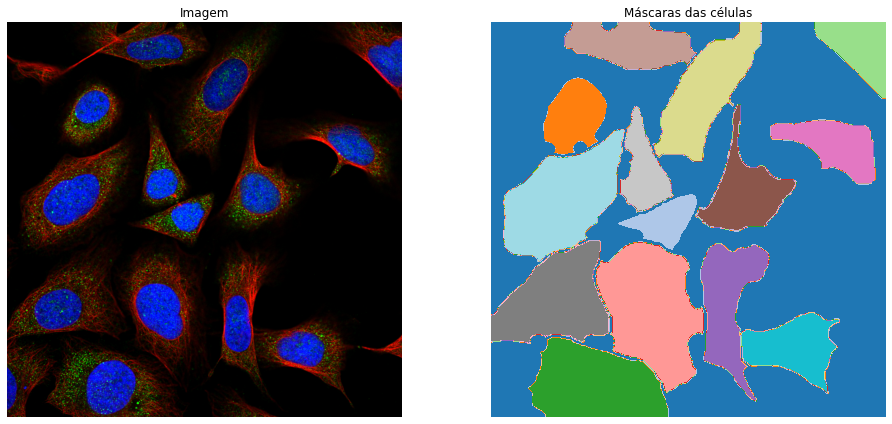

In [33]:
if PUBLIC_TEST:
    image_id = '0040581b-f1f2-4fbe-b043-b6bfea5404bb'
    
    # carregar imagem
    rgb_image = load_rgb_image(directory, image_id)
    H, W = rgb_image.shape[:2]
    
    # montar máscara
    cell_mask = build_cell_mask_from_df(tm, image_id, H, W)
    
    # plotar
    plot_image_and_masks(rgb_image, cell_mask)

In [34]:
sample_submission_df = pd.read_csv('../input/hpa-single-cell-image-classification/sample_submission.csv', index_col=0)
sample_submission_df.head()

,ImageWidth,ImageHeight,PredictionString
ID,,,
0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
004a270d-34a2-4d60-bbe4-365fca868193,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
00537262-883c-4b37-a3a1-a4931b6faea5,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
00c9a1c9-2f06-476f-8b0d-6d01032874a2,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
0173029a-161d-40ef-af28-2342915b22fb,3072,3072,0 1 eNoLCAgIsAQABJ4Beg==


In [35]:
class SliceInferenceDataset(torch.utils.data.Dataset):
    def __init__(self, df, tta=16, cfg=None, tfms=None, deterministic=False):
        self.df = df                                  # DataFrame contendo informações de imagem_id e codificação da máscara
        self.iids = self.df.image_id.unique()         # Lista única de IDs de imagem
        self.tta = tta                                # Número de Test Time Augmentations a serem aplicados
        self.deterministic = deterministic
    
    def __len__(self):
        return len(self.iids)                         # Número total de imagens únicas

    def __getitem__(self, idx):
        iid = self.iids[idx]                          # Pega o image_id pelo índice
        
        # Lê os canais de imagem correspondentes a cada cor (em escala de cinza)
        mt = f'../input/hpa-single-cell-image-classification/test/{iid}_red.png'
        er = f'../input/hpa-single-cell-image-classification/test/{iid}_yellow.png'
        nu = f'../input/hpa-single-cell-image-classification/test/{iid}_blue.png'
        pr = f'../input/hpa-single-cell-image-classification/test/{iid}_green.png'
        r = cv2.imread(mt, 0).astype(np.float) / 255.0
        g = cv2.imread(pr, 0).astype(np.float) / 255.0
        b = cv2.imread(nu, 0).astype(np.float) / 255.0
        a = cv2.imread(er, 0).astype(np.float) / 255.0
        
        sz = r.shape[0]                               # Assume imagem quadrada (W = H)
        img = np.stack([r, g, b, a], -1)              # Empilha os 4 canais para criar imagem 4-channel RGBY
        
        sli = []                                       # Lista para armazenar os crops das células (imagem + fname)
        
        # Itera sobre todas as células daquela imagem
        for i, x in self.df[self.df.image_id == iid].iterrows():
            # Decodifica a máscara RLE
            bd = base64.b64decode(x.enc)
            zd = zlib.decompress(bd)
            encoded = [{'counts': zd, 'size': (sz, sz)}]
            ded = coco_mask.decode(encoded)[:, :, 0]  # Máscara binária

            # Se não tiver célula detectada
            if len(np.unique(ded)) == 1:
                continue

            # Extrai bounding box da máscara
            xr, yr = np.where(ded == 1)
            sub = img[xr.min(): xr.max(), yr.min(): yr.max()]  # Recorta imagem
            crop_sub_mask = ded[xr.min(): xr.max(), yr.min(): yr.max()]
            crop_sub_mask = np.repeat(crop_sub_mask[:, :, np.newaxis], 4, axis=2)  # Expande máscara para 4 canais
            
            # Aplica máscara à imagem
            r = sub * crop_sub_mask

            # Ajusta para quadrado e redimensiona para 256×256
            sli.append((cv2.resize(squarify(r, 0), (256, 256)).astype(np.float32), x.fname))

        # Se nenhuma célula válida foi extraída da imagem, retorna None
        if not sli:
            return None
        
        BS, tta = len(sli) + 1, self.tta  # BS: batch size estimado (número de células + 1)
        ipts = []                         # Lista de batches de células com TTA

        raw_ipt = [e[0] for e in sli]     # Apenas as imagens (sem o fname)

        # Aplica transformações de TTA
        if tta == 1:
            ipts.append(torch.stack([tensor_tfms(res_tfms(image=x)['image']) for x in raw_ipt]).float())
        else:
            if not self.deterministic:
                for tt in range(tta):
                    ipts.append(torch.stack([tensor_tfms(tta_tfms(image=x)['image']) for x in raw_ipt]).float())
            else:
                transforms = []
                for flip in [False, True]:
                    for k in range(4):
                        transforms.append((flip, k))
                for flip, k in transforms[:tta]:
                    batch = []
                    for x in raw_ipt:
                        xr = x
                        if flip:
                            xr = np.flip(xr, axis=1)
                        xr = np.rot90(xr, k).copy()
                        xr = res_tfms(image=xr)['image']
                        xr = tensor_tfms(xr)
                        batch.append(xr)
                    ipts.append(torch.stack(batch).float())

        # Também transforma a imagem inteira para outro uso (ex: CAM)
        image = image_tfms(image_res_tfms(image=img)['image'])
            
        # Retorna:
        # - imagem da amostra inteira (RGBY)
        # - células da imagem após TTA
        # - batch size estimado
        # - número de células detectadas
        # - número de TTA
        # - image_id
        # - lista dos nomes de arquivos para cada célula
        return image, ipts, BS, len(sli), tta, iid, [x[1] for x in sli]

In [36]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

sid = SliceInferenceDataset(tm, tta=8, deterministic=False)
dl = torch.utils.data.DataLoader(sid, batch_size=1, num_workers=2, worker_init_fn=seed_worker)

In [37]:
# Move os modelos para GPU e define modo de avaliação (desativa dropout, batchnorm)
cell_models = [model.cuda().eval() for model in models]
image_models = [model.cuda().eval() for model in image_models]

# Listas para armazenar predições
cell_predictions_dfs = []        # Para armazenar predições por célula
image_predictions_dfs = []       # Para armazenar predições por imagem (whole image prediction)

# Loop sobre o DataLoader de inferência (dl)
contador = 0
for full_image, cell_inputs_tta, batch_size_tensor, num_cells_tensor, tta_tensor, image_id, cell_filenames_raw in tqdm.tqdm(dl):
    # Extração e formatação das variáveis
    batch_size = batch_size_tensor.item()           # Tamanho do batch
    num_tta = tta_tensor.item()                     # Número de Test Time Augmentations
    image_id = image_id[0]                          # image_id (string)
    cell_filenames = [name[0] for name in cell_filenames_raw]  # Nomes dos arquivos das células
    num_cells = num_cells_tensor.item()             # Número de células na imagem
    
    cell_predictions_batches = []  # Lista para armazenar as predições de células
    image_predictions_batches = [] # Lista para armazenar as predições da imagem inteira

    # Processamento das células em blocos do tamanho do batch
    for start_idx in range(0, num_cells, batch_size):
        with torch.no_grad():
            res = []  # Predições por célula (para cada modelo com TTA)
            exp = []  # Predições da imagem inteira (para cada modelo)
            
            # Inferência da imagem completa com modelos de imagem (ex: Puzzle-CAM)
            for model in image_models:
                full_image = full_image.float().cuda()
                model = model.float() 
                exp.append(model(full_image))

            # Inferência por TTA: aplica vários modelos às células com augmentations
            for tta_idx in range(num_tta):
                cell_batch = cell_inputs_tta[tta_idx][0].cuda() 
                for model in cell_models:
                    with torch.cuda.amp.autocast():
                        cell_output, image_output = model(cell_batch, len(cell_batch))
                    res.append(cell_output.float()) 
                    exp.append(image_output.float())

        # Média das predições de cada célula com sigmoid (multi-label)
        cell_prob = [torch.sigmoid(r.cpu()) for r in res]
        image_prob = [torch.sigmoid(r.cpu()) for r in exp]
        
        cell_probs_mean = np.stack(cell_prob).mean(0)
        image_probs_mean = np.stack(image_prob).mean(0)

        cell_predictions_batches.append(cell_probs_mean)
        image_predictions_batches.append(image_probs_mean)

    # Concatena predições por célula (final do loop da imagem)
    cell_predictions = np.concatenate(cell_predictions_batches)
    cell_df = pd.DataFrame(cell_predictions, index=cell_filenames)
    
    image_df = pd.DataFrame(
        np.concatenate(image_predictions_batches).mean(0).reshape(1, 19), 
        index=[image_id]
    )

    # Salva resultados
    image_predictions_dfs.append(image_df)
    cell_predictions_dfs.append(cell_df)

    del full_image, cell_inputs_tta
    gc.collect()
    torch.cuda.empty_cache()

    contador += 1
    if contador % 10 == 0:
        print_memory_usage()

  2%|▏         | 10/559 [00:28<19:46,  2.16s/it]

RAM Usada: 2521.30 MB


  4%|▎         | 20/559 [00:46<17:07,  1.91s/it]

RAM Usada: 2441.32 MB


  5%|▌         | 30/559 [00:59<12:43,  1.44s/it]

...

 97%|█████████▋| 540/559 [17:42<00:28,  1.48s/it]

RAM Usada: 2459.62 MB


 98%|█████████▊| 550/559 [18:09<00:32,  3.57s/it]

RAM Usada: 2555.71 MB


100%|██████████| 559/559 [18:26<00:00,  1.98s/it]


In [38]:
# Concatena todos os DataFrames de predição por imagem (gerados durante a inferência)
# Isso resulta em um DataFrame onde cada linha representa uma imagem (image_id) com predições para cada classe
image_level = pd.concat(image_predictions_dfs)

# Junta o DataFrame `image_level` com o DataFrame `tm`, para associar os image_id com seus nomes de arquivo (fname)
# - `reset_index()` move o índice (que contém image_id) para uma coluna chamada 'index'
# - `merge(..., how='left')` garante que todos os dados de `image_level` sejam mantidos
# - `on='index'` (de `image_level`) se conecta com `image_id` (de `tm`)
image_pred = image_level.reset_index().merge(
    tm[['image_id', 'fname']],  # Subconjunto com apenas as colunas relevantes do `tm`
    left_on='index',            # Usa o antigo índice como chave de junção
    right_on='image_id',        # Faz a junção com a coluna image_id do `tm`
    how='left'                  # Preserva todas as linhas de `image_level`
)
# Organiza o DataFrame final:
# - Define 'fname' como índice, o que facilita o acesso por nome de célula depois
# - Remove as colunas 'index' (image_id original do image_level) e 'image_id' (duplicado do tm)
image_pred = image_pred.set_index('fname').drop(['index', 'image_id'], axis=1)

In [39]:
# Concatena todos os DataFrames de predições por célula (armazenados em `pdfs`)
# Cada DataFrame em `pdfs` contém predições de classes para as células daquela imagem, indexadas por fname (ex: "abc_1")
pub_pred = pd.concat(cell_predictions_dfs)

# Multiplica as predições por célula (`pub_pred`) pelas predições a nível de imagem (`image_pred`)
# - Ambas têm o mesmo índice (fname, como "abc_1"), então a operação é feita elemento a elemento
# - Isso pode ser interpretado como um reponderamento das predições da célula com base na imagem
#   (por exemplo, se a imagem não tiver forte ativação para uma classe, a predição da célula será atenuada)
merge_pred = pub_pred * image_pred.loc[pub_pred.index]

## If any ensemble

In [40]:
merge_pred.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0040581b-f1f2-4fbe-b043-b6bfea5404bb_1,0.056292,5.414744e-07,0.009358,0.001267,1.326971e-06,0.001050,0.000002,3.172248e-06,3.630939e-07,0.000017,1.473327e-06,3.932105e-10,0.000085,4.242782e-07,2.984168e-07,0.000141,0.130358,0.000022,3.214396e-09
0040581b-f1f2-4fbe-b043-b6bfea5404bb_2,0.006181,1.476676e-05,0.001780,0.000260,1.261848e-07,0.001045,0.000025,1.041472e-06,2.196697e-07,0.000022,2.855047e-07,1.669254e-09,0.000379,1.396902e-06,2.244451e-07,0.000173,0.243961,0.000122,5.968093e-09
0040581b-f1f2-4fbe-b043-b6bfea5404bb_3,0.003800,1.648046e-06,0.002153,0.000703,4.555164e-07,0.001352,0.000063,5.817379e-07,5.285155e-07,0.000038,2.605696e-07,1.409162e-09,0.000102,1.680475e-06,1.782513e-07,0.000167,0.376965,0.000023,1.234850e-08
0040581b-f1f2-4fbe-b043-b6bfea5404bb_4,0.035794,1.244188e-05,0.043034,0.003116,1.149396e-06,0.000596,0.000025,3.064881e-06,6.555375e-07,0.000056,4.900078e-07,4.926828e-09,0.000171,7.169950e-06,7.831778e-07,0.000147,0.026090,0.000010,3.540550e-08
0040581b-f1f2-4fbe-b043-b6bfea5404bb_5,0.015970,1.754178e-06,0.007455,0.002505,2.533607e-07,0.007187,0.000013,1.135303e-06,5.477126e-07,0.000023,1.175035e-07,1.555781e-09,0.000140,1.856551e-06,3.179763e-07,0.000439,0.054316,0.000002,3.664818e-08


## Save prediction

In [41]:
merge_pred.index.name = 'fname' # Define o nome do índice de `merge_pred` como 'fname'
merge_pred = merge_pred.reset_index() # Reseta o índice de `merge_pred`, transformando 'fname' em uma coluna normal
tm = tm.set_index('fname') # Define a coluna 'fname' como índice do DataFrame `tm`

# Cria uma nova coluna 'ID' em `merge_pred`, extraindo a parte antes do "_" da coluna 'fname'
# Exemplo: se fname = "abc_3", então ID = "abc"
merge_pred['ID'] = merge_pred['fname'].str.split('_', expand=True)[0]

In [42]:
# Lista para armazenar as predições finais formatadas por imagem
j_pred = []

# Itera sobre todos os IDs únicos (ou seja, imagens únicas) presentes no DataFrame `merge_pred`
for iid in merge_pred.ID.unique():
    enc = ''  # Inicializa a string de predição para essa imagem

    # Filtra `merge_pred` para obter apenas as linhas (células) associadas ao ID atual (imagem atual)
    sub_df = merge_pred[merge_pred.ID == iid]

    # Para cada célula da imagem
    for idx, row in sub_df.iterrows():
        # Para cada uma das 19 classes (0 a 18), cria um trecho do tipo: "class prob mask"
        for i in range(19):
            enc += f'{i} {row[i]} {tm.loc[row.fname].enc} '
    
    # Adiciona a predição formatada como um dicionário na lista `j_pred`
    # Remove o último espaço de `enc` com `[:-1]`
    j_pred.append({
        'ID': iid,  # ID da imagem
        'ImageWidth': sample_submission_df.loc[iid].ImageWidth,   # Largura da imagem (obtida do DataFrame original `df`)
        'ImageHeight': sample_submission_df.loc[iid].ImageHeight, # Altura da imagem
        'PredictionString': enc[:-1]  # String com todas as predições no formato esperado para submissão
    })


In [43]:
# Converte a lista de dicionários `j_pred` em um DataFrame do pandas
fast_sub = pd.DataFrame(j_pred)

# Salva esse DataFrame em um arquivo CSV chamado 'pub.csv'
# Esse arquivo será formatado como exigido para submissão na competição (ID, ImageWidth, ImageHeight, PredictionString)
fast_sub.to_csv('pub.csv', index=False)

# Define a coluna 'ID' como índice do DataFrame (útil para buscas e manipulações futuras)
fast_sub = fast_sub.set_index('ID')


In [44]:
fast_sub.head(2)

,ImageWidth,ImageHeight,PredictionString
ID,,,
0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048,0 0.05629204586148262 eNqVUj0LwyAQ/UtKDuLg0KGD...
004a270d-34a2-4d60-bbe4-365fca868193,2048,2048,0 1.445391808374552e-05 eNqdlFFvwiAQx78S53jA2Y...


## save

In [45]:
sample_submission_df

,ImageWidth,ImageHeight,PredictionString
ID,,,
0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
004a270d-34a2-4d60-bbe4-365fca868193,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
00537262-883c-4b37-a3a1-a4931b6faea5,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
00c9a1c9-2f06-476f-8b0d-6d01032874a2,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
0173029a-161d-40ef-af28-2342915b22fb,3072,3072,0 1 eNoLCAgIsAQABJ4Beg==
...,...,...,...
fea47298-266a-4cf4-93bd-55d1bcc2fc7d,1728,1728,0 1 eNoLCAjJNgIABNkBkg==
feb955db-6c07-4717-a98b-92236c8e01d8,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==
fefb9bb7-934a-40d1-8d2f-210265857388,2048,2048,0 1 eNoLCAgIMAEABJkBdQ==


In [46]:
# Substitui as previsões do DataFrame `sample_submission_df` pelas do `fast_sub`
# drop(fast_sub.index): remove as linhas de 'sample_submission_df' que já estão em 'fast_sub' (com mesmo ID)
# depois concatena com 'fast_sub' para manter as novas previsões
sub2 = pd.concat([sample_submission_df.drop(fast_sub.index), fast_sub], axis=0)

# Reordena as linhas para seguir exatamente a ordem original de 'sample_submission_df'
sub2 = sub2.loc[sample_submission_df.index]

# Salva o novo DataFrame como CSV no formato de submissão exigido
sub2.to_csv('submission.csv')

In [47]:
sub2

,ImageWidth,ImageHeight,PredictionString
ID,,,
0040581b-f1f2-4fbe-b043-b6bfea5404bb,2048,2048,0 0.05629204586148262 eNqVUj0LwyAQ/UtKDuLg0KGD...
004a270d-34a2-4d60-bbe4-365fca868193,2048,2048,0 1.445391808374552e-05 eNqdlFFvwiAQx78S53jA2Y...
00537262-883c-4b37-a3a1-a4931b6faea5,2048,2048,0 0.0002536098472774029 eNqNUr0KAyEMfqVcyeDg4O...
00c9a1c9-2f06-476f-8b0d-6d01032874a2,2048,2048,0 9.820931882131845e-05 eNqLycyIMrZJyTc0AAETGw...
0173029a-161d-40ef-af28-2342915b22fb,3072,3072,0 0.009044604375958443 eNqFkLsSgyAQRX9pZZiJBUU...
...,...,...,...
fea47298-266a-4cf4-93bd-55d1bcc2fc7d,1728,1728,0 0.0001229671761393547 eNqtlE1vwyAMhv8SbpAWTT...
feb955db-6c07-4717-a98b-92236c8e01d8,2048,2048,0 9.478907304583117e-05 eNrLyUtMMAwxzMkzNAABFx...
fefb9bb7-934a-40d1-8d2f-210265857388,2048,2048,0 0.04116255044937134 eNqNUTtvgzAQ/kt3hMEDA4MH...
